# Task 1.2: 양자 연산 적용하기 (Part 1)
## Objective 1a: 기본 회로 라이브러리

**개요:**
이 노트북에서는 Qiskit의 기본 구성 요소를 다룹니다.
*   **표준 게이트(Standard Gates):** 파울리 게이트, 하다마드 게이트, 제어 게이트
*   **디렉티브(Directives):** 측정, 배리어, 리셋
*   **산술 연산(Arithmetic):** 기본 가산기와 기저 변환 (QFT, 양자푸리에변환)


In [1]:
# 설정: 필요한 라이브러리 가져오기
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter, Instruction, Gate
from qiskit.circuit.library import *
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)

print("라이브러리를 성공적으로 불러왔습니다.")

라이브러리를 성공적으로 불러왔습니다.


### 표준 게이트

* 가역적이며 유니터리인 양자 게이트들입니다.
* `MCXGate`처럼 수학적 작용으로 정의되는 추상 연산을 포함하며, 이러한 연산은 서로 다른 분해 방식으로 구현될 수 있습니다.
* 또한 구조적 연산도 포함합니다. 이들은 고유한 분해를 가지며, `real_amplitudes`처럼 양자 회로를 반환하는 함수 형태로 구현됩니다.


In [2]:
from qiskit.circuit.library import XGate

xgate = XGate()
print(f"XGate 행렬:\n{xgate.to_matrix()}")
print(f"√X 행렬:\n{xgate.power(1/2).to_matrix()}")
print(f"CX 게이트:\n{xgate.control(1).to_matrix()}")
print(f"CX 게이트:\n{xgate.control(1)}")

XGate 행렬:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
√X 행렬:
[[0.5+0.5j 0.5-0.5j]
 [0.5-0.5j 0.5+0.5j]]
CX 게이트:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]
CX 게이트:
Instruction(name='cx', num_qubits=2, num_clbits=0, params=[])


In [3]:
from qiskit.circuit.library import get_standard_gate_name_mapping

print(f"Qiskit의 표준 게이트:{get_standard_gate_name_mapping().keys()}")

Qiskit의 표준 게이트:dict_keys(['id', 'sx', 'x', 'cx', 'rz', 'r', 'c3sx', 'ccx', 'dcx', 'ch', 'cp', 'crx', 'cry', 'crz', 'cswap', 'csx', 'cu', 'cu1', 'cu3', 'cy', 'cz', 'ccz', 'global_phase', 'h', 'p', 'rccx', 'rcccx', 'rx', 'rxx', 'ry', 'ryy', 'rzz', 'rzx', 'xx_minus_yy', 'xx_plus_yy', 'ecr', 's', 'sdg', 'cs', 'csdg', 'swap', 'iswap', 'sxdg', 't', 'tdg', 'u', 'u1', 'u2', 'u3', 'y', 'z', 'delay', 'reset', 'measure'])


#### 1큐비트 표준 게이트

* `HGate` : 단일 큐비트 하다마드 게이트
* `IGate` : 항등 게이트
* `PhaseGate` : Z축에 대한 단일 큐비트 회전 게이트 $\mathrm{e}^{-\mathrm{i}\theta (I+Z)/2}$
* `RGate` : $\cos⁡(\phi)x + \sin⁡(\phi)y$ 축을 중심으로 각도 $\theta$만큼 회전하는 게이트 $R(\theta, \phi)=\mathrm{e}^{-\mathrm{i}\theta(\cos⁡(\phi)X + \sin⁡(\phi)Y)/2}$
* `RXGate` : X축에 대한 단일 큐비트 회전 게이트 $\mathrm{e}^{-\mathrm{i}\theta X/2}$
* `RYGate` : Y축에 대한 단일 큐비트 회전 게이트 $\mathrm{e}^{-\mathrm{i}\theta Y/2}$
* `RZGate` : Z축에 대한 단일 큐비트 회전 게이트 $\mathrm{e}^{-\mathrm{i}\theta Z/2}$
* `SGate` : 단일 큐비트 S 게이트 $(Z^{0.5})$
* `SdgGate` : 단일 큐비트 S의 수반(adjoint) 게이트 $(Z^{0.5 \dagger})$
* `SXGate` : 단일 큐비트 $\sqrt{X}$ 게이트 (SX)
* `SXdgGate` : 단일 큐비트 $\sqrt{X}$ 게이트의 역연산
* `TGate` : 단일 큐비트 T 게이트 $(Z^{0.25})$
* `TdgGate` : 단일 큐비트 T의 수반(adjoint) 게이트 $(Z^{0.25 \dagger})$
* `UGate` : ZYZ 오일러 각으로 표현되는 일반적인 단일 큐비트 회전 게이트
  $$U(\theta, \phi, \lambda)=P(\phi)R_Y(\theta)P(\lambda)=\begin{bmatrix} \cos(\theta/2) & -\mathrm{e}^{\mathrm{i}\lambda}\sin(\theta/2)\\ \mathrm{e}^{\mathrm{i}\phi}\sin(\theta/2) & \mathrm{e}^{\mathrm{i}(\phi+\lambda)}\cos(\theta/2)\end{bmatrix}$$
* `U1Gate` : Z축에 대한 단일 큐비트 회전 게이트 $U1(\theta)=P(\theta)=U(0,0,\theta)$
* `U2Gate` : X+Z 축에 대한 단일 큐비트 회전 게이트 $U2(\phi, \lambda)=U(\pi/2, \phi, \lambda)$
* `U3Gate` : 3개의 오일러 각으로 표현되는 일반적인 단일 큐비트 회전 게이트 $U3(\theta, \phi, \lambda)=U(\theta, \phi, \lambda)$
* `XGate` : 단일 큐비트 파울리-X 게이트 $(\sigma_x)$
* `YGate` : 단일 큐비트 파울리-Y 게이트 $(\sigma_y)$
* `ZGate` : 단일 큐비트 파울리-Z 게이트 $(\sigma_z)$


In [4]:
# PhaseGate, RZ Gate, U1Gate의 차이

from qiskit.circuit.library import PhaseGate
theta = np.pi/2
phase_gate = PhaseGate(theta)
rz_gate = RZGate(theta)
u1_gate = U1Gate(theta)
print(f"PhaseGate 행렬:\n{phase_gate.to_matrix()}")
print(f"RZGate 행렬:\n{rz_gate.to_matrix()}")
print(f"U1Gate 행렬:\n{u1_gate.to_matrix()}")

# PhaseGate는 RZGate와 달리 global phase를 포함합니다.
# 따라서, PhaseGate의 행렬은 RZGate의 행렬에 global phase factor exp(i*theta/2)를 곱한 형태입니다.
print(np.allclose(phase_gate.to_matrix(), rz_gate.to_matrix() * np.exp(1j * theta / 2)))

# PhaseGate와 U1Gate의 행렬은 동일합니다.
print(np.allclose(phase_gate.to_matrix(), u1_gate.to_matrix()))

PhaseGate 행렬:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
RZGate 행렬:
[[0.71-0.71j 0.  +0.j  ]
 [0.  +0.j   0.71+0.71j]]
U1Gate 행렬:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
True
True


In [5]:
from qiskit.circuit.library import HGate

hgate = HGate()
print(f"Hadamard 게이트 행렬:{hgate.to_matrix()}")

Hadamard 게이트 행렬:[[ 0.71+0.j  0.71+0.j]
 [ 0.71+0.j -0.71+0.j]]


In [6]:
from qiskit.circuit.library import SXdgGate

sxdggate = SXdgGate()
print(f"SX Dagger 게이트 행렬:{sxdggate.to_matrix()}")

SX Dagger 게이트 행렬:[[0.5-0.5j 0.5+0.5j]
 [0.5+0.5j 0.5-0.5j]]


#### 2큐비트 표준 게이트

* `CHGate` : 제어 하다마드 게이트
* `CPhaseGate` : 제어 위상 게이트
* `CRXGate` : 제어 RX 게이트
* `CRYGate` : 제어 RY 게이트
* `CRZGate` : 제어 RZ 게이트
* `CSGate` : 제어 S 게이트
* `CSdgGate` : 제어 $S^\dagger$ 게이트
* `CSXGate` : 제어 $\sqrt{X}$ 게이트
* `CUGate` : 제어 U 게이트 (4개 매개변수를 갖는 2큐비트 게이트)
* `CU1Gate` : 제어 U1 게이트
* `CU3Gate` : 제어 U3 게이트 (3개 매개변수를 갖는 2큐비트 게이트)
* `CXGate` : 제어 X 게이트
* `CYGate` : 제어 Y 게이트
* `CZGate` : 제어 Z 게이트
* `DCXGate` : 이중 CNOT 게이트
* `ECRGate` : echoed cross-resonance 게이트
* `iSwapGate` : iSWAP 게이트
* `RXXGate` : $R_{XX}(\phi)=\mathrm{e}^{-\mathrm{i} \phi XX/2}$. 2큐비트 $XX=X\otimes X$ 상호작용을 나타내는 매개변수형 게이트 (해밀토니안 $H=XX$ 시뮬레이션, XX축 회전)
* `RYYGate` : $R_{YY}(\phi)=\mathrm{e}^{-\mathrm{i} \phi YY/2}$. 2큐비트 $YY=Y\otimes Y$ 상호작용을 나타내는 매개변수형 게이트 (해밀토니안 $H=YY$ 시뮬레이션, YY축 회전)
* `RZXGate` : $R_{ZX}(\phi)=\mathrm{e}^{-\mathrm{i} \phi ZX/2}$. 2큐비트 $ZX=Z\otimes X$ 상호작용을 나타내는 매개변수형 게이트 (해밀토니안 $H=ZX$ 시뮬레이션, ZX축 회전)
* `RZZGate` : $R_{ZZ}(\phi)=\mathrm{e}^{-\mathrm{i} \phi ZZ/2}$. 2큐비트 $ZZ=Z\otimes Z$ 상호작용을 나타내는 매개변수형 게이트 (해밀토니안 $H=ZZ$ 시뮬레이션, ZZ축 회전)
* `SwapGate` : SWAP 게이트
* `XXMinusYYGate` : XX-YY 상호작용 게이트
* `XXPlusYYGate` : XX+YY 상호작용 게이트


In [7]:
from qiskit.circuit.library import CHGate

chgate = CHGate()
print(f"제어 Hadamard 게이트 행렬:\n{chgate.to_matrix()}")

제어 Hadamard 게이트 행렬:
[[ 1.  +0.j  0.  +0.j  0.  +0.j  0.  +0.j]
 [ 0.  +0.j  0.71+0.j  0.  +0.j  0.71+0.j]
 [ 0.  +0.j  0.  +0.j  1.  +0.j  0.  +0.j]
 [ 0.  +0.j  0.71+0.j  0.  +0.j -0.71+0.j]]


In [8]:
from qiskit.circuit.library import SwapGate

swapgate = SwapGate()
print(f"SwapGate 행렬:\n{swapgate.to_matrix()}")

SwapGate 행렬:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


#### 3큐비트 이상 표준 게이트

* `C3SXGate` : 3개의 제어 큐비트를 갖는 $\sqrt{X}$ 게이트
* `C3XGate` : 3개의 제어 큐비트를 갖는 X 게이트
* `C4XGate` : 4개의 제어 큐비트를 갖는 X 게이트
* `CCXGate` : CCX 게이트, 토폴리(Toffoli) 게이트라고도 함
* `CCZGate` : CCZ 게이트
* `CSwapGate` : 제어 SWAP 게이트, 프레드킨(Fredkin) 게이트라고도 함
* `RCCXGate` : 단순화된 토폴리 게이트, 마골루스(Margolus) 게이트라고도 함
* `RC3XGate` : 단순화된 3중 제어 토폴리 게이트


In [9]:
from qiskit.circuit.library import CCXGate

ccxgate = CCXGate()
print(f"Toffoli 게이트 행렬:\n{ccxgate.to_matrix()}")

Toffoli 게이트 행렬:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


#### 전역 표준 게이트

* `GlobalPhaseGate` : 전역 위상 게이트 $(e^{i\theta})$

In [10]:
from qiskit.circuit.library import GlobalPhaseGate
import numpy as py

gpgate = GlobalPhaseGate(py.pi/2)
print(f"전역 위상 행렬:{ccxgate.to_matrix()}")

전역 위상 행렬:[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


### 표준 디렉티브

* `Barrier`처럼 백엔드나 트랜스파일러가 해석하도록 의도된 연산입니다.

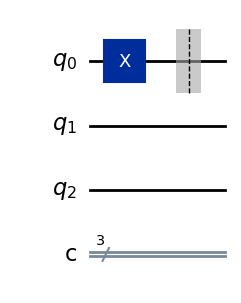

In [11]:
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import Barrier

b=Barrier(1)
qc= QuantumCircuit(3,3)
qc.compose(xgate).compose(b).draw('mpl')

### 표준 연산

* **Measure** : 계산 기저에서의 측정
* **Reset** : 큐비트를 $|0\rangle$ 상태로 초기화


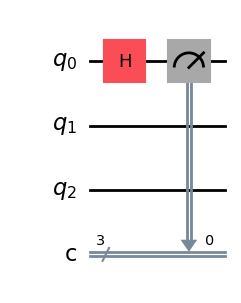

In [12]:
from qiskit.circuit.library import Measure
measure =Measure()
qc.compose(hgate).compose(measure).draw('mpl')

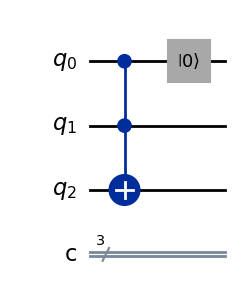

In [13]:
from qiskit.circuit.library import Reset
reset =Reset()
qc.compose(ccxgate).compose(reset).draw('mpl')

### 일반화된 게이트

* 표준 게이트를 확장한 개념입니다.
* 큐비트 수가 입력에 따라 달라지는 가변(variadic) 게이트를 포함합니다.
* 일반적으로는 `QuantumCircuit`보다 `Instruction` 또는 `Gate`를 상속하는 게이트를 사용하는 것이 권장됩니다. `Instruction`과 `Gate`는 컴파일러가 더 추상적인 수준에서 의미를 해석할 수 있지만, `QuantumCircuit`는 즉시 구체적인 회로로 구성되기 때문입니다.


In [14]:
from qiskit.circuit.library import DiagonalGate
 
diagonal = DiagonalGate([1, 1j])
print(diagonal.num_qubits)
 
diagonal = DiagonalGate([1, 1, 1, -1])
print(diagonal.num_qubits)

1
2


**게이트 또는 인스트럭션 표현**

* `DiagonalGate` : 일반적인 대각 양자 게이트
* `PermutationGate` : 큐비트들의 순서를 치환하는 게이트. 예를들어 `[2, 4, 3, 0, 1]` 입력이 주어지면, 큐비트2가 위치0, 큐비트4가 위치1로 변함.
* `MCMTGate` : 임의의 단일 제어 대상 게이트에 대한 다중 제어-다중 타깃 게이트
* `MCPhaseGate` : 다중 제어 위상 게이트
* `MCXGate` : 일반적인 다중 제어 X 게이트
* `MSGate` : Mølmer–Sørensen 게이트
* `RVGate` : 임의의 회전축 $v$ 주위의 회전 게이트. 여기서 $\|v\|_2$는 라디안 단위 회전각입니다. $R(\mathbf{v})=\mathrm{e}^{-\mathrm{i}\,\mathbf{v}\cdot\mathbf{\sigma}/2}$
* `PauliGate` : 다중 큐비트 파울리 게이트
* `LinearFunction` : $n$ 큐비트 위의 선형 가역 회로
* `Isometry` : $m$ 큐비트에서 $n$ 큐비트로의 임의 등거리 사상(isometry) 분해. ($m=n$인 경우 유니터리, $m=0$이면 상태준비)
* `UnitaryGate` : 유니터리 행렬로 지정되는 양자 게이트 클래스
* `UCGate` : 균일 제어 게이트 (multiplexed gate라고도 함) $\oplus_{i=0}^{2^{k-1}} U_i$
* `UCPauliRotGate` : 균일 제어 파울리 회전 게이트
* `UCRXGate` : 균일 제어 파울리-X 회전 게이트
* `UCRYGate` : 균일 제어 파울리-Y 회전 게이트
* `UCRZGate` : 균일 제어 파울리-Z 회전 게이트

**QuantumCircuit 표현**

* ~~`Diagonal`~~ **(deprecated v2.1)** : 대각 변환을 구현하는 회로
* ~~`MCMT`~~ **(deprecated v1.4)** : 임의의 단일 제어 대상 게이트에 대한 다중 제어-다중 타깃 게이트
* ~~`MCMTVChain`~~ **(deprecated v1.4)** : CCX V-chain을 사용하는 MCMT 구현
* `MCXGrayCode` : 그레이 코드(Gray code)를 사용한 다중 제어 X 게이트 구현
* `MCXRecursive` : 재귀를 사용한 다중 제어 X 게이트 구현
* `MCXVChain` : CX 게이트의 V-chain을 사용한 다중 제어 X 게이트 구현
* ~~`Permutation`~~ **(deprecated v2.1)** : 큐비트를 치환하는 \(n\)-큐비트 회로
* ~~`GMS`~~ **(deprecated v2.1)** : 전역 Mølmer–Sørensen 게이트
* `GR` : 전역 R 게이트
* `GRX` : 전역 RX 게이트
* `GRY(num_qubits, theta)` : 전역 RY 게이트
* `GRZ(num_qubits, phi)` : 전역 RZ 게이트


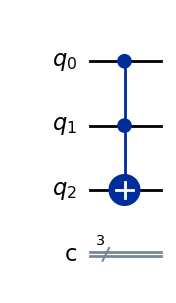

In [15]:
from qiskit.circuit.library import MCXGate

mcxgate = MCXGate(num_ctrl_qubits=2)
qc.compose(mcxgate).draw('mpl')

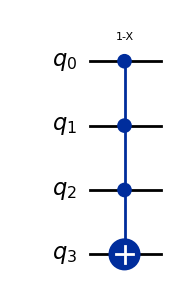

In [16]:
from qiskit.circuit.library import MCMTGate

mcmtGate = MCMTGate(gate=xgate,num_ctrl_qubits=3,num_target_qubits=1)
qc= QuantumCircuit(4,0)
qc.compose(mcmtGate).draw('mpl')

### 불리언 논리 게이트

**게이트 표현**

* `AndGate` : 여러 큐비트에 대해 논리 AND 연산을 표현하는 게이트
* `OrGate` : 여러 큐비트에 대해 논리 OR 연산을 표현하는 게이트
* `BitwiseXorGate` : 입력에 어떤 정수 값을 비트 단위 XOR 하는 $n$-큐비트 게이트
* `InnerProductGate` : 두 $n$-큐비트 벡터의 $\mathbb{F}_2$ 상 내적을 계산하는 $2n$-큐비트 불리언 함수

**QuantumCircuit 표현**

* ~~`AND`~~ (deprecaed v2.1) : 여러 큐비트에 대한 논리 AND 연산을 구현하는 회로
* ~~`OR`~~ (deprecaed v2.1) : 여러 큐비트에 대한 논리 OR 연산을 구현하는 회로
* ~~`XOR`~~ (deprecaed v2.1) : 입력에 어떤 정수 값을 비트 단위 XOR 하는 $n$-큐비트 회로
* ~~`InnerProduct`~~ (deprecaed v2.1) : 두 $n$-큐비트 벡터의 $\mathbb{F}_2$ 상 내적을 계산하는 $2n$-큐비트 불리언 함수


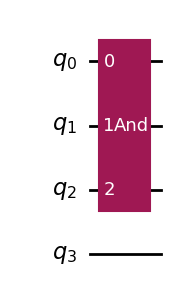

In [17]:
from qiskit.circuit.library import AndGate

andgate = AndGate(num_variable_qubits=2)

qc.compose(andgate).draw('mpl')

### 기저 변환 게이트

* `QFTGate`처럼 큐비트 상태의 기저를 변환하는 게이트입니다.

**게이트 표현**

* `QFTGate` : 양자 푸리에 변환 게이트

**양자 회로 표현**

* ~~`QFT`~~ (deprecaed v2.1) : 양자 푸리에 변환 회로


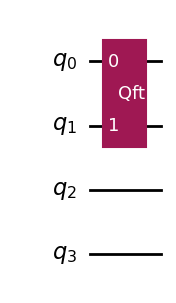

In [18]:
from qiskit.circuit.library import QFTGate

qftgate=QFTGate(2)
qc.compose(qftgate).draw('mpl')

### 산술 게이트

#### 가산기 게이트

**게이트 표현**

* `ModularAdderGate` : 두 개의 $n$-큐비트 레지스터의 합을 $2^n$ 모듈로로 계산 ($|a\rangle_n|b\rangle_n\rightarrow|a\rangle_n|a+b~\mathrm{mod}2^n\rangle_n$)
* `HalfAdderGate` : 같은 크기의 두 큐비트 레지스터의 합을 계산하며, carry-out 비트를 포함 ($|a\rangle_n|b\rangle_n\rightarrow|a\rangle_n|a+b\rangle_{n+1}$)
* `FullAdderGate` : 두 개의 $n$-큐비트 레지스터의 합을 계산하며, carry-in 및 carry-out 비트를 포함 ($|c_{\mathrm{in}}\rangle_1|a\rangle_n|b\rangle_n\rightarrow|a\rangle_n|c_{\mathrm{in}}+a+b\rangle_{n+1}$)

**QuantumCircuit 표현**

* `DraperQFTAdder` : 두 큐비트 레지스터에 대해 QFT를 이용한 in-place 덧셈 회로
* `CDKMRippleCarryAdder` : 두 큐비트 레지스터에 대해 in-place 덧셈을 수행하는 ripple-carry 회로
* `VBERippleCarryAdder` : VBE ripple-carry 가산기


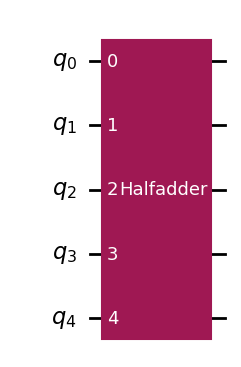

In [19]:
from qiskit.circuit.library import HalfAdderGate

qc=QuantumCircuit(5)
hagate=HalfAdderGate(2)
qc.compose(hagate).draw('mpl')

#### 곱셈기

**게이트 표현**

* `MultiplierGate` : 같은 크기의 두 큐비트 레지스터의 곱을 새로운 레지스터에 계산 ($|a\rangle_n|b\rangle_n|0\rangle_t\rightarrow|a\rangle_n|b\rangle_{n}|a\cdot b\rangle_t$) ($t\ge 2n$)

**QuantumCircuit 표현**

* `HRSCumulativeMultiplier` : 두 입력 레지스터의 곱을 out-of-place 방식으로 저장하는 곱셈 회로
* `RGQFTMultiplier` : 두 입력 레지스터의 곱을 out-of-place 방식으로 저장하는 QFT 기반 곱셈 회로


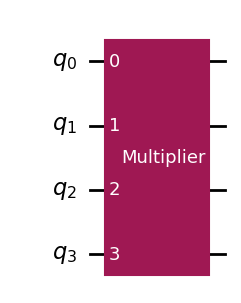

In [20]:
from qiskit.circuit.library import MultiplierGate

qc=QuantumCircuit(4)
mgate=MultiplierGate(1,2)
qc.compose(mgate).draw('mpl')

#### 진폭 함수

**게이트 표현**

* `LinearAmplitudeFunctionGate` : 큐비트 진폭 위에 (구간별) 선형 함수를 구현하는 회로. 일반적으로 함수 $f = 	{slope}*x + 	{offset}$는 어떤 구간 $[a,b]$의 정의역(domain)에서 $[c,d]$의 치역(image)으로 정의됩니다.
  $$F|x\rangle|0\rangle = \sqrt{1-f(x)}|x\rangle|0\rangle +  \sqrt{f(x)}|x\rangle|1\rangle $$

**QuantumCircuit 표현**

* ~~`LinearAmplitudeFunction`~~ **(deprecated v2.2)** : 큐비트 진폭 위에 (구간별) 선형 함수를 구현하는 회로


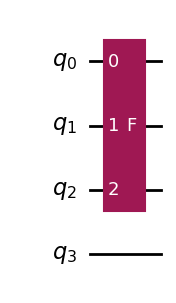

In [21]:
from qiskit.circuit.library import LinearAmplitudeFunctionGate

qc=QuantumCircuit(4)
lafgate=LinearAmplitudeFunctionGate(num_state_qubits=2,slope=1.0,offset=0,domain=[0,1],image=[0,1,2,3])
qc.compose(lafgate).draw('mpl')

#### 함수형 파울리 회전

**게이트 표현**

* `LinearPauliRotationsGate` : 선형적으로 제어되는 X, Y 또는 Z 회전
* `PolynomialPauliRotationsGate` : 다항식 파울리 회전을 구현하는 게이트
* `PiecewiseLinearPauliRotationsGate` : 구간별 선형 제어 파울리 회전
* `PiecewisePolynomialPauliRotationsGate` : 구간별 다항식 제어 파울리 회전
* `PiecewiseChebyshevGate` : 입력 함수에 대한 구간별 체비쇼프 근사

**QuantumCircuit 표현**

* `FunctionalPauliRotations` : 함수형 파울리 회전의 기본 클래스
* `LinearPauliRotations` : 선형적으로 제어되는 X, Y 또는 Z 회전
* `PolynomialPauliRotations` : 다항식 파울리 회전을 구현하는 회로
* `PiecewiseLinearPauliRotations` : 구간별 선형 제어 파울리 회전
* ~~`PiecewisePolynomialPauliRotations`~~ (**Deprecated v2.2**) : 구간별 다항식 제어 파울리 회전
* `PiecewiseChebyshev` : 입력 함수에 대한 구간별 체비쇼프 근사



## 예제 - LinearPauliRotations

아래 예제는 Qiskit 라이브러리의 **`LinearPauliRotations`** 클래스를 사용합니다. 앞서 제시한 분류에 따르면, 이 구성 요소는 **`QuantumCircuit`을 상속하는 클래스**에 해당합니다.

### 1. 개요
`LinearPauliRotations`는 특수한 양자 회로 라이브러리 구성 요소입니다. 이 클래스는 상태(제어) 큐비트에 저장된 정수값의 선형 함수로 회전 각도가 결정되는 제어 회전을 구현합니다.

### 2. 수학적 정의
이 회로는 타깃 큐비트에 회전 $R_{\text{basis}}(\theta)$를 적용하며, 각도 $\theta$는 다음과 같이 계산됩니다.

$$ \theta = \text{slope} \times x + \text{offset} $$

*   **$x$**: 상태(제어) 큐비트가 나타내는 정수값
*   **slope**: 정수값이 한 단계 증가할 때 회전각이 변하는 비율
*   **offset**: $x = 0$일 때의 시작 각도
*   **basis**: 회전축 ($X$, $Y$, 또는 $Z$)

### 3. 스크립트에서의 구현
`quantum_example.py`에서는 다음과 같은 설정으로 회로를 생성합니다.

*   **기저:** `'Y'` ($R_y$ 회전을 구현)
*   **상태 큐비트 수:** 2 (입력 $x$ 역할을 하며, 가능한 정수값은 $0, 1, 2, 3$)
*   **식:** $\theta = 0.5x + 0.2$

```python
lpr_circuit = LinearPauliRotations(
    num_state_qubits=2,
    slope=0.5,
    offset=0.2,
    basis='Y'
)
```

### 4. 구성 요소 분류
앞의 분류 목록에서 보았듯이, 이 클래스는 `Gate`가 아니라 `QuantumCircuit`을 상속합니다.

*   **중요한 이유:** `QuantumCircuit`이므로, 이 객체는 표준 기본 게이트들(CNOT, 단일 큐비트 회전 등)로 구성된 복합 객체입니다.
*   **사용 방식:** 스크립트에서는 하나의 블록처럼 취급되며, `.append()` 메서드로 메인 회로에 추가됩니다.
    ```python
    # qc.append(circuit_object, qubit_indices)
    qc.append(lpr_circuit, range(num_state_qubits + num_target_qubits))
    ```

### 5. 회로 구조
스크립트에서 `lpr_circuit.decompose().draw()`를 호출하면 내부 구조를 확인할 수 있습니다.
1.  **입력:** "state" 큐비트 레지스터와 "target" 큐비트 레지스터
2.  **연산:** 선형 공식에 따라 각 상태 큐비트의 기여를 회전에 반영하기 위해, 일련의 제어 회전들(보통 CNOT과 단일 큐비트 회전으로 분해됨)을 사용합니다.


In [22]:
try:
    from qiskit import QuantumCircuit
    from qiskit.circuit.library import LinearPauliRotations
except ImportError:
    print("오류: Qiskit이 설치되어 있지 않습니다. 'pip install qiskit'으로 설치해 주세요.")
    exit(1)

def example_linear_pauli_rotations():
    """
    LinearPauliRotations 회로를 보여줍니다.

    LinearPauliRotations는 제어 레지스터의 상태에 따라
    회전각이 선형 함수로 결정되는 회전을 구현합니다.

    회전각: theta = slope * x + offset
    여기서 x는 제어 레지스터의 정수값입니다.
    """

    # 선형 함수의 매개변수
    slope = 0.5
    offset = 0.2

    # 상태 큐비트(제어) 수와 타깃 큐비트 수 정의
    num_state_qubits = 2
    num_target_qubits = 1

    # LinearPauliRotations 회로 생성
    # basis='Y'는 Ry 회전을 수행한다는 뜻입니다.
    lpr_circuit = LinearPauliRotations(
        num_state_qubits=num_state_qubits,
        slope=slope,
        offset=offset,
        basis='Y'
    )

    print("--- LinearPauliRotations 회로 ---")
    print(lpr_circuit.draw())

    # 구현 세부사항(분해 결과) 확인
    print("\n--- 분해된 회로 ---")
    print(lpr_circuit.decompose().draw())

    # 더 큰 회로에 통합하는 예시
    print("\n--- 더 큰 회로에 통합한 예시 ---")
    qc = QuantumCircuit(num_state_qubits + num_target_qubits)

    # 상태 큐비트 초기화 (예: 중첩 상태로)
    qc.h(range(num_state_qubits))

    # LinearPauliRotations 회로 추가
    # 앞의 'num_state_qubits'개는 제어, 마지막 'num_target_qubits'개는 타깃입니다.
    qc.append(lpr_circuit, range(num_state_qubits + num_target_qubits))

    print(qc.draw())

if __name__ == "__main__":
    try:
        example_linear_pauli_rotations()
    except ImportError:
        print("오류: Qiskit이 설치되어 있지 않습니다. 'pip install qiskit'으로 설치해 주세요.")

--- LinearPauliRotations 회로 ---
         ┌──────────────┐
state_0: ┤0             ├
         │              │
state_1: ┤1 Linpaulirot ├
         │              │
 target: ┤2             ├
         └──────────────┘

--- 분해된 회로 ---
                                        
state_0: ────────────────■──────────────
                         │              
state_1: ────────────────┼─────────■────
         ┌─────────┐┌────┴────┐┌───┴───┐
 target: ┤ Ry(0.2) ├┤ Ry(0.5) ├┤ Ry(1) ├
         └─────────┘└─────────┘└───────┘

--- 더 큰 회로에 통합한 예시 ---
     ┌───┐┌─────────┐
q_0: ┤ H ├┤0        ├
     ├───┤│         │
q_1: ┤ H ├┤1 LinRot ├
     └───┘│         │
q_2: ─────┤2        ├
          └─────────┘


---

## 연습 문제

**1. 상태 $|0\rangle$에 하다마드(H) 게이트를 적용하면 어떤 효과가 나타나는가?**

A) $|0\rangle$

B) $|1\rangle$

C) $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$

D) $\frac{|0\rangle - |1\rangle}{\sqrt{2}}$

***정답:***
<Details>
<br/>
C) $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$
</Details>

---

**2. 회로의 특정 경계를 기준으로 트랜스파일러가 최적화를 넘나들지 못하도록 막는 Qiskit 디렉티브는 무엇인가?**

A) Measure

B) Reset

C) Barrier

D) Delay

***정답:***
<Details>
<br/>
C) Barrier
</Details>

---

**3. CCX 게이트(토폴리 게이트)는 다음 중 어떤 경우에만 타깃 큐비트에 X(NOT) 연산을 적용하는가?**

A) 두 제어 큐비트가 모두 상태 $|0\rangle$ 일 때

B) 두 제어 큐비트가 모두 상태 $|1\rangle$ 일 때

C) 제어 큐비트 중 하나만 상태 $|1\rangle$ 일 때

D) 적어도 하나의 제어 큐비트가 상태 $|0\rangle$ 일 때

***정답:***
<Details>
<br/>
B) 두 제어 큐비트가 모두 상태 $|1\rangle$
</Details>